# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random

# Base class for logging/messaging - helps us debug and track game events
class base:
    SILENT=0
    DEBUG=1
    INFO=2
    WARNING=3
    ERROR=4
    CRITICAL=5
    
    def __init__(self,level=0):
        self.level=level
    
    def message(self,level,*args):
        if level>=self.level:
            print(*args)


# Card class - represents a single playing card
class Card(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades", "ShuffleCard"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]
    
    def __init__(self, suit, value=None):
        base.__init__(self)
        self.__suit = suit if suit in self.__suits else None
        self.__value = value if value in self.__values else None
        
        # Validation - make sure card is legit
        if self.__suit is None:
            self.message(self.ERROR,"Error, bad suit:",suit)
        
        if self.__value is None and self.__suit != "ShuffleCard":
            self.message(self.ERROR,"Error, bad value:",value)
    
    def value(self):
        return self.__value
    
    def suit(self):
        return self.__suit
    
    def numerical_value(self):
        # Special handling of aces - they can be 1 or 11
        if self.__value == "Ace":
            return 1
        elif self.__value in ["Jack","Queen","King"]:
            return 10
        else:
            return self.__value
    
    def shuffle_card(self):
        return self.__suit == "ShuffleCard"
    
    def __str__(self):
        if self.shuffle_card():
            return "Shuffle Card"
        else:
            return str(self.__value) + " of " + self.__suit
    
    __repr__ = __str__


# Deck class - manages multiple 52-card decks plus a shuffle card
class Deck(base):
    __suits = ["Clubs","Diamonds","Hearts","Spades"]
    __values = list(range(2,11)) + ["Jack","Queen","King","Ace"]
    
    def __init__(self,n_decks=6):
        base.__init__(self)
        self.__n_decks=n_decks
        
        self.__cards = list()
        
        # Build the deck from scratch
        for _ in range(self.__n_decks):
            self.__cards.extend(self.__make_deck())
        
        # Add shuffle card randomly in the deck
        self.__cards.append(Card("ShuffleCard"))
    
    def __make_deck(self):
        deck=list()
        for suit in self.__suits:
            for value in self.__values:
                deck.append(Card(suit,value))
        return deck
    
    def shuffle(self):
        random.shuffle(self.__cards)
    
    def deal(self):
        if len(self.__cards)>0:
            return self.__cards.pop()
        else:
            # Ran out of cards, need to rebuild
            for _ in range(self.__n_decks):
                self.__cards.extend(self.__make_deck())
            self.shuffle()
            return self.__cards.pop()

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [2]:
import random

# Base class for logging/messaging - helps us debug and track game events
class base:
    SILENT=0
    DEBUG=1
    INFO=2
    WARNING=3
    ERROR=4
    CRITICAL=5
    
    def __init__(self,level=0):
        self.level=level
    
    def message(self,level,*args):
        if level>=self.level:
            print(*args)


# Card class - represents a single playing card
class Card(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades", "ShuffleCard"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]
    
    def __init__(self, suit, value=None):
        base.__init__(self)
        self.__suit = suit if suit in self.__suits else None
        self.__value = value if value in self.__values else None
        
        # Validation - make sure card is legit
        if self.__suit is None:
            self.message(self.ERROR,"Error, bad suit:",suit)
        
        if self.__value is None and self.__suit != "ShuffleCard":
            self.message(self.ERROR,"Error, bad value:",value)
    
    def value(self):
        return self.__value
    
    def suit(self):
        return self.__suit
    
    def numerical_value(self):
        # Special handling of aces - they can be 1 or 11
        if self.__value == "Ace":
            return 1
        elif self.__value in ["Jack","Queen","King"]:
            return 10
        else:
            return self.__value
    
    def shuffle_card(self):
        return self.__suit == "ShuffleCard"
    
    def __str__(self):
        if self.shuffle_card():
            return "Shuffle Card"
        else:
            return str(self.__value) + " of " + self.__suit
    
    __repr__ = __str__


# Deck class - manages multiple 52-card decks plus a shuffle card
class Deck(base):
    __suits = ["Clubs","Diamonds","Hearts","Spades"]
    __values = list(range(2,11)) + ["Jack","Queen","King","Ace"]
    
    def __init__(self,n_decks=6):
        base.__init__(self)
        self.__n_decks=n_decks
        
        self.__cards = list()
        
        # Build the deck from scratch
        for _ in range(self.__n_decks):
            self.__cards.extend(self.__make_deck())
        
        # Add shuffle card randomly in the deck
        self.__cards.append(Card("ShuffleCard"))
    
    def __make_deck(self):
        deck=list()
        for suit in self.__suits:
            for value in self.__values:
                deck.append(Card(suit,value))
        return deck
    
    def shuffle(self):
        random.shuffle(self.__cards)
    
    def deal(self):
        if len(self.__cards)>0:
            return self.__cards.pop()
        else:
            # Ran out of cards, need to rebuild
            for _ in range(self.__n_decks):
                self.__cards.extend(self.__make_deck())
            self.shuffle()
            return self.__cards.pop()


# Helper function to calculate hand value - handles Aces as 1 or 11
def calc_hand_value(hand):
    pass  # Will implement in Q4


# Player base class - all players inherit from this
class PlayerBase(base):
    def __init__(self, name, n_chips):
        base.__init__(self)
        self.__name = name
        self.__n_chips = n_chips
    
    def name(self):
        return self.__name
    
    def chips(self):
        return self.__n_chips
    
    def pay(self, value=2):
        # Add chips when player wins
        pass
    
    def deduct(self, value=2):
        # Remove chips when player loses
        pass
    
    def play_hand(self, down_card, up_cards, seen_cards):
        # Decide whether to hit or stay - each player type implements this differently
        raise NotImplementedError
    
    def __str__(self):
        return self.__name + " (" + str(self.__n_chips) + ")"
    
    __repr__ = __str__


# Dealer player - follows house rules (hit on 16, stay on 17+)
class DealerPlayer(PlayerBase):
    def __init__(self, threshold=16):
        self.__threshold = threshold
        PlayerBase.__init__(self,"Mr. Dealer",1000)
    
    def play_hand(self, down_card, up_cards, seen_cards):
        # Dealer hits if hand value < threshold
        pass


# Human player - asks user for input
class ConsolePlayer(PlayerBase):
    def play_hand(self, down_card, up_cards, seen_cards):
        # Print hand and ask user to hit or stay
        pass


# Game class - runs the blackjack game
class Game(base):
    def __init__(self, n_decks=6):
        base.__init__(self, self.INFO)
        self.__n_decks = n_decks
        self.__players = list()
        self.__all_players = list()
        
        self.__shuffle = False
    
    def players(self):
        return self.__players
    
    def all_players(self):
        return self.__all_players
    
    def add_player(self, player):
        # Add a player to the game
        pass
    
    def deal_and_check_shuffle(self, deck):
        # Deal a card and check if it's the shuffle card
        pass
    
    def show_status(self, hands, seen_cards):
        # Display game status to players
        pass
    
    def play_game(self, n_hands):
        # Main game loop - play n_hands rounds
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [3]:
import random

# Base class for logging/messaging - helps us debug and track game events
class base:
    SILENT=0
    DEBUG=1
    INFO=2
    WARNING=3
    ERROR=4
    CRITICAL=5
    
    def __init__(self,level=0):
        self.level=level
    
    def message(self,level,*args):
        if level>=self.level:
            print(*args)


# Card class - represents a single playing card
class Card(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades", "ShuffleCard"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]
    
    def __init__(self,suit,value=None):
        base.__init__(self)
        self.__suit = suit if suit in self.__suits else None
        self.__value = value if value in self.__values else None
        
        # Validation - make sure card is legit
        if self.__suit is None:
            self.message(self.ERROR,"Error, bad suit:",suit)
        
        if self.__value is None and self.__suit!="ShuffleCard":
            self.message(self.ERROR,"Error, bad value:",value)
    
    def value(self):
        return self.__value
    
    def suit(self):
        return self.__suit
    
    def numerical_value(self):
        # Special handling of aces - they can be 1 or 11
        if self.__value=="Ace":
            return 1
        elif self.__value in ["Jack","Queen","King"]:
            return 10
        else:
            return self.__value
    
    def shuffle_card(self):
        return self.__suit=="ShuffleCard"
    
    def __str__(self):
        if self.shuffle_card():
            return "Shuffle Card"
        else:
            return str(self.__value) + " of " + self.__suit
    
    __repr__=__str__


# Deck class - manages multiple 52-card decks plus a shuffle card
class Deck(base):
    __suits = ["Clubs","Diamonds","Hearts","Spades"]
    __values = list(range(2,11)) + ["Jack","Queen","King","Ace"]
    
    def __init__(self,n_decks=6):
        base.__init__(self)
        self.__n_decks=n_decks
        
        self.__cards=list()
        
        # Build the deck from scratch
        for _ in range(self.__n_decks):
            self.__cards.extend(self.__make_deck())
        
        # Add shuffle card randomly in the deck
        self.__cards.append(Card("ShuffleCard"))
    
    def __make_deck(self):
        deck=list()
        for suit in self.__suits:
            for value in self.__values:
                deck.append(Card(suit,value))
        return deck
    
    def shuffle(self):
        random.shuffle(self.__cards)
    
    def deal(self):
        if len(self.__cards)>0:
            return self.__cards.pop()
        else:
            # Ran out of cards, need to rebuild
            for _ in range(self.__n_decks):
                self.__cards.extend(self.__make_deck())
            self.shuffle()
            return self.__cards.pop()


# Helper function to calculate hand value - handles Aces as 1 or 11
def calc_hand_value(hand):
    card_values=list(map(lambda card: card.numerical_value(),hand))
    
    # Count how many aces we have
    n_As= len(list(filter(lambda x: x==1,card_values)))
    
    hand_value=sum(card_values)
    
    # Try to use aces as 11 if it doesn't bust
    if n_As==0:
        return hand_value
    
    # Case where last Ace is counted as 1
    Ace_as_one=hand_value
    Ace_as_eleven=hand_value+10
    
    if Ace_as_eleven<=21:
        return Ace_as_eleven
    else:
        return Ace_as_one


# Player base class - all players inherit from this
class PlayerBase(base):
    def __init__(self,name,n_chips):
        base.__init__(self)
        self.__name=name
        self.__n_chips=n_chips
    
    def name(self):
        return self.__name
    
    def chips(self):
        return self.__n_chips
    
    def pay(self,value=2):
        # Add chips when player wins
        self.__n_chips+=value
    
    def deduct(self,value=2):
        # Remove chips when player loses
        self.__n_chips-=value
    
    def play_hand(self,down_card,up_cards,seen_cards):
        # Decide whether to hit or stay - each player type implements this differently
        raise NotImplementedError
    
    def __str__(self):
        return self.__name + " (" + str(self.__n_chips) + ")"
    
    __repr__=__str__


# Dealer player - follows house rules (hit on 16, stay on 17+)
class DealerPlayer(PlayerBase):
    def __init__(self,threshold=16):
        self.__threshold=threshold
        PlayerBase.__init__(self,"Mr. Dealer",1000)
    
    def play_hand(self,down_card,up_cards,seen_cards):
        # Dealer hits if hand value < threshold
        hand_value=calc_hand_value([down_card]+up_cards)
        return hand_value<self.__threshold


# Human player - asks user for input
class ConsolePlayer(PlayerBase):
    def play_hand(self,down_card,up_cards,seen_cards):
        # Print hand and ask user to hit or stay
        print("Down Card:",down_card)
        print("Up Cards:",up_cards)
        print("Seen Cards:",seen_cards)
        hit_str=input("Hit(Y/N):")
        return hit_str.upper()=="Y"


# Game class - runs the blackjack game
class Game(base):
    def __init__(self,n_decks=6):
        base.__init__(self,self.INFO)
        self.__n_decks=n_decks
        self.__players=list()
        self.__all_players=list()
        
        self.__shuffle=False
    
    def players(self):
        return self.__players
    
    def all_players(self):
        return self.__all_players
    
    def add_player(self,player):
        # Add a player to the game
        self.__players.append(player)
        self.__all_players.append(player)
    
    def deal_and_check_shuffle(self,deck):
        # Deal a card and check if it's the shuffle card
        card=deck.deal()
        if card.shuffle_card():
            shuffle=True
            card=deck.deal()
        return card
    
    def show_status(self,hands,seen_cards):
        # Display game status to players
        self.message(self.INFO,"----------------------------------------")
        self.message(self.INFO,"Hands:",hands)
        self.message(self.INFO,"Seen Cards:",seen_cards)
        self.message(self.INFO,"----------------------------------------")
        self.message(self.INFO,"Players:")
        self.message(self.INFO,"----------------------------------------")
    
    def play_game(self,n_hands):
        # Main game loop - play n_hands rounds
        # Create Dealer
        self.add_player(DealerPlayer())
        
        deck=None
        self.__shuffle=False
        
        # TODO: Check that all players have chips...
        
        for i_hand in range(n_hands):
            
            # Remove Players with no money
            self.__players=list(filter(lambda player: player.chips()>=2,self.__players))
            self.message(self.DEBUG,"n players, n all players",len(self.__players),len(self.__all_players))
            self.message(self.DEBUG,"Starting Hand:",i_hand,"/",n_hands)
            # New Hand
            
            # Do we have a deck or have to shuffle?
            if deck is None or self.__shuffle:
                self.message(self.DEBUG,"Creating New Deck / Shuffling")
                deck=Deck()
                # Shuffle Cards
                deck.shuffle()
                seen_cards=list()
                self.__shuffle=False
            
            hands=list()
            
            # Deal Each Players Hand
            # Down card deal
            self.message(self.DEBUG,"Dealing Cards")
            for player_i,player in enumerate(self.__players):
                down_card=self.deal_and_check_shuffle(deck)
                up_cards=list()
                hands.append([down_card,up_cards])
                if player_i < len(self.__players)-1:
                    seen_cards.append(down_card)
            
            # Up card deal
            for (down_card,up_cards) in hands:
                up_cards.append(self.deal_and_check_shuffle(deck))
                seen_cards.append(up_cards[-1])
            
            # TODO: Show hands...
            self.show_status(hands,seen_cards)
            
            # Play
            # Deals cards and asks players to hit/stay
            
            for player_i,((down_card,up_cards),player) in enumerate(zip(hands,self.__players)):
                self.message(self.DEBUG,"Asking Player",player_i,"to Play")
                self.message(self.DEBUG,"Player",player_i,"hand total:",calc_hand_value([down_card]+up_cards))
                hit=True
                this_hand_up_cards=list()
                while(hit):
                    hit=player.play_hand(down_card,up_cards,seen_cards)
                    
                    if hit:
                        self.message(self.DEBUG,"Player",player_i,"Hit")
                        card=self.deal_and_check_shuffle(deck)
                        up_cards.append(card)
                        this_hand_up_cards.append(card)
                        hand_value=calc_hand_value([down_card]+up_cards)
                        self.message(self.DEBUG,"Hand Value:",hand_value)
                        if hand_value<21:
                            hit=True
                        else:
                            hit=False
                            if hand_value>21:
                                self.message(self.DEBUG,"Player",player_i,"Busted")
                            else:
                                self.message(self.DEBUG,"Player",player_i,"Got 21")
                    else:
                        self.message(self.DEBUG,"Player",player_i,"Stay")
                
                seen_cards.append(down_card)
                seen_cards.extend(this_hand_up_cards)
            
            # Pay:
            # Compute the hand values
            hand_values=[calc_hand_value([hand[0]]+hand[1]) for hand in hands]
            
            self.message(self.DEBUG,"Hand Values",hand_values)
            
            # Determine who gets paid
            if hand_values[-1]==21:
                self.message(self.DEBUG,"Dealer Got 21")
                for player_i,(hand_value,player) in enumerate(zip(hand_values[:-1],self.__players[:-1])):
                    if hand_value==21:
                        self.message(self.DEBUG,"Player",player_i,"Got 21. Paying 3 chips.")
                        player.pay(3)
                    else:
                        self.message(self.DEBUG,"Player",player_i,"Busted or dealer won. Deducting 2 chips.")
                        player.deduct(2)
            
            if hand_values[-1]>21:
                self.message(self.DEBUG,"Dealer Busted")
                for player_i,(hand_value,player) in enumerate(zip(hand_values[:-1],self.__players[:-1])):
                    if hand_value==21:
                        self.message(self.DEBUG,"Player",player_i,"Got 21. Paying 3 chips.")
                        player.pay(3)
                    elif hand_value>21:
                        self.message(self.DEBUG,"Player",player_i,"Busted. Deducting 2 chips.")
                        player.deduct(2)
                    else:
                        self.message(self.DEBUG,"Player",player_i,"Paying 2 chips.")
                        player.pay(2)
            
            if hand_values[-1]<21:
                self.message(self.DEBUG,"Dealer hand is:",hand_values[-1])
                for player_i,(hand_value,player) in enumerate(zip(hand_values[:-1],self.__players[:-1])):
                    if hand_value==21:
                        self.message(self.DEBUG,"Player",player_i,"Got 21. Paying 3 chips.")
                        player.pay(3)
                    elif hand_value>21:
                        self.message(self.DEBUG,"Player",player_i,"Busted. Deducting 2 chips.")
                        player.deduct(2)
                    else:
                        self.message(self.DEBUG,"Player",player_i,"Paying 2 chips.")
                        player.pay(2)

In [4]:
## LLM usage

# I was having a hard time deciding how to structure the main game loop, more specifically dealing with the order of dealing cards and figuring out the logic for different payouts based on win/loss situations.
# I asked LLM to help me think through the flow of a blackjack round and how to handle the chip payment system based on possible outcomes- and it helped edit my code.

# Heres what i took away from this problem: it is very important to break down a complex game into smaller steps to make it much more manageable. The llm also showed me how to use the enumerate and zip functions to iterate through both of the players hands at the same time, which was really useful.


5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [5]:
# Test the game with multiple players following dealer strategy

my_game=Game()

# Add some players that follow dealer rules
my_game.add_player(DealerPlayer(threshold=16))
my_game.add_player(DealerPlayer(threshold=16))
my_game.add_player(DealerPlayer(threshold=16))

# Play a few rounds
my_game.play_game(5)

print("\n\nFinal chip counts:")
for player in my_game.all_players():
    print(player)

----------------------------------------
Hands: [[King of Diamonds, [7 of Diamonds]], [3 of Clubs, [7 of Spades]], [3 of Diamonds, [4 of Hearts]], [10 of Clubs, [9 of Hearts]]]
Seen Cards: [King of Diamonds, 3 of Clubs, 3 of Diamonds, 7 of Diamonds, 7 of Spades, 4 of Hearts, 9 of Hearts]
----------------------------------------
Players:
----------------------------------------
----------------------------------------
Hands: [[6 of Clubs, [2 of Hearts]], [7 of Clubs, [5 of Hearts]], [4 of Clubs, [6 of Hearts]], [Queen of Spades, [Jack of Spades]]]
Seen Cards: [King of Diamonds, 3 of Clubs, 3 of Diamonds, 7 of Diamonds, 7 of Spades, 4 of Hearts, 9 of Hearts, King of Diamonds, 3 of Clubs, Jack of Clubs, 3 of Diamonds, 4 of Hearts, 2 of Spades, 5 of Spades, 10 of Clubs, 6 of Clubs, 7 of Clubs, 4 of Clubs, 2 of Hearts, 5 of Hearts, 6 of Hearts, Jack of Spades]
----------------------------------------
Players:
----------------------------------------
----------------------------------------


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [6]:
# Card counting strategy player
# Assigns values: 2-6 = +1, 7-9 = 0, 10-Ace = -1
# Hits when count is very negative (deck has mostly high cards left)
# Stays when count is very positive (deck has mostly low cards left)

class Strategy_1_Player(PlayerBase):
    def __init__(self,threshold=0):
        self.__threshold=threshold
        PlayerBase.__init__(self,"Strategy Player",1000)
    
    def play_hand(self,down_card,up_cards,seen_cards):
        # Calculate running count
        count=0
        for card in seen_cards:
            val=card.numerical_value()
            if val>=2 and val<=6:
                count+=1
            elif val>=7 and val<=9:
                count+=0
            else:  # 10,J,Q,K,A
                count-=1
        
        # Check current hand value
        hand_value=calc_hand_value([down_card]+up_cards)
        
        # Don't hit if at 21 or busted
        if hand_value>=21:
            return False
        
        # Hit if count < threshold (negative count = hit more)
        return count<self.__threshold

In [7]:
# Test the strategy player

my_game=Game()

# Add strategy player
my_game.add_player(Strategy_1_Player(threshold=0))

# Play some rounds
my_game.play_game(10)

print("\n\nFinal chip counts:")
for player in my_game.all_players():
    print(player)

----------------------------------------
Hands: [[2 of Hearts, [7 of Hearts]], [Ace of Spades, [7 of Spades]]]
Seen Cards: [2 of Hearts, 7 of Hearts, 7 of Spades]
----------------------------------------
Players:
----------------------------------------
----------------------------------------
Hands: [[5 of Diamonds, [3 of Spades]], [8 of Spades, [3 of Spades]]]
Seen Cards: [2 of Hearts, 7 of Hearts, 7 of Spades, 2 of Hearts, Ace of Spades, 5 of Diamonds, 3 of Spades, 3 of Spades]
----------------------------------------
Players:
----------------------------------------
----------------------------------------
Hands: [[9 of Clubs, [10 of Clubs]], [9 of Spades, [6 of Diamonds]]]
Seen Cards: [2 of Hearts, 7 of Hearts, 7 of Spades, 2 of Hearts, Ace of Spades, 5 of Diamonds, 3 of Spades, 3 of Spades, 5 of Diamonds, 8 of Spades, 3 of Clubs, Ace of Hearts, Queen of Diamonds, 9 of Clubs, 10 of Clubs, 6 of Diamonds]
----------------------------------------
Players:
----------------------------

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [8]:
my_game=Game()
my_game.level=my_game.CRITICAL  # Only show critical errors

# Add the strategy player
my_game.add_player(Strategy_1_Player(threshold=0))

# Add 3 players that follow dealer's strategy
my_game.add_player(DealerPlayer(threshold=16))
my_game.add_player(DealerPlayer(threshold=16))
my_game.add_player(DealerPlayer(threshold=16))

# Play 50 rounds
my_game.play_game(50)

print("\n========================================")
print("Final Results After 50 Rounds:")
print("========================================")
for player in my_game.all_players():
    print(player)

# Calculate strategy player's winnings
strategy_player=my_game.all_players()[0]
winnings=strategy_player.chips()-1000

print("\nStrategy Player Winnings:",winnings)
print("Average per round:",winnings/50)


Final Results After 50 Rounds:
Strategy Player (1041)
Mr. Dealer (1025)
Mr. Dealer (1042)
Mr. Dealer (1047)
Mr. Dealer (1000)

Strategy Player Winnings: 41
Average per round: 0.82


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Running 100 games...
  20/100 complete
  40/100 complete
  60/100 complete
  80/100 complete
  100/100 complete

Results:
Average winnings: $19.13
Standard deviation: $41.44
Average per round: $0.38
Wins: 65/100
Losses: 35/100


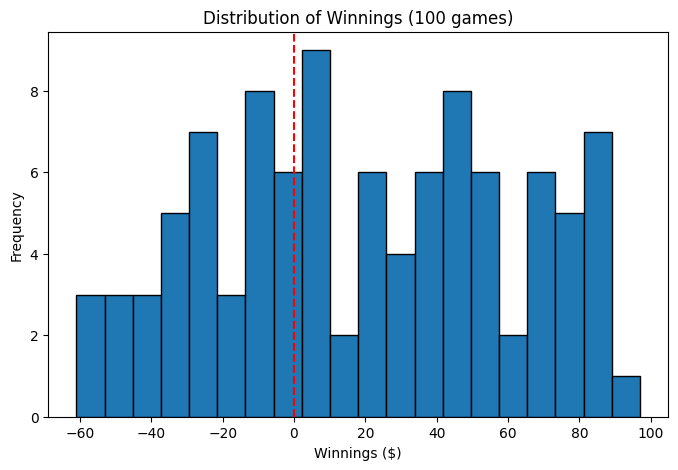

In [11]:
import matplotlib.pyplot as plt
import numpy as np

winnings_list=[]

print("Running 100 games...")

for game_num in range(100):
    my_game=Game()
    my_game.level=my_game.CRITICAL
    
    my_game.add_player(Strategy_1_Player(threshold=0))
    my_game.add_player(DealerPlayer(threshold=16))
    my_game.add_player(DealerPlayer(threshold=16))
    my_game.add_player(DealerPlayer(threshold=16))
    
    my_game.play_game(50)
    
    strategy_player=my_game.all_players()[0]
    winnings=strategy_player.chips()-1000
    winnings_list.append(winnings)
    
    if (game_num+1)%20==0:
        print(f"  {game_num+1}/100 complete")

# Statistics
winnings_array=np.array(winnings_list)
avg_winnings=np.mean(winnings_array)
std_winnings=np.std(winnings_array)
avg_per_round=avg_winnings/50

n_wins=sum(1 for w in winnings_list if w>0)
n_losses=sum(1 for w in winnings_list if w<0)

print("\n========================================")
print("Results:")
print("========================================")
print(f"Average winnings: ${avg_winnings:.2f}")
print(f"Standard deviation: ${std_winnings:.2f}")
print(f"Average per round: ${avg_per_round:.2f}")
print(f"Wins: {n_wins}/100")
print(f"Losses: {n_losses}/100")

# Histogram
plt.figure(figsize=(8,5))
plt.hist(winnings_list,bins=20,edgecolor='black')
plt.xlabel('Winnings ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Winnings (100 games)')
plt.axvline(x=0,color='red',linestyle='--')
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?


Testing threshold=-5...
  Average: $44.30

Testing threshold=-2...
  Average: $24.18

Testing threshold=0...
  Average: $17.12

Testing threshold=2...
  Average: $5.28

Testing threshold=5...
  Average: $-7.84

Summary:
Threshold -5: $44.30
Threshold -2: $24.18
Threshold 0: $17.12
Threshold 2: $5.28
Threshold 5: $-7.84


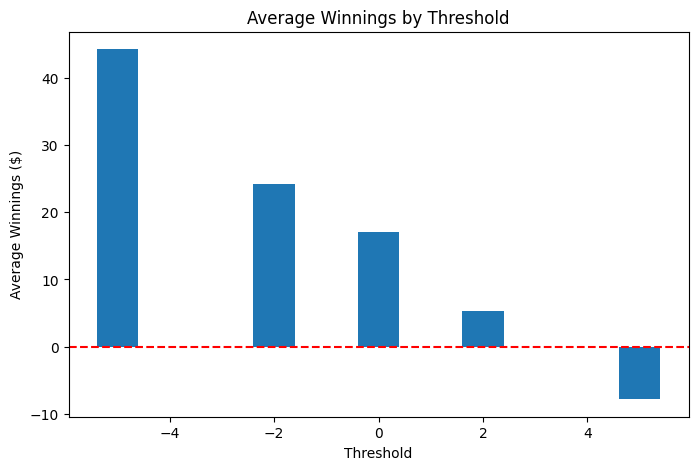

In [10]:
# Try different thresholds
thresholds=[-5,-2,0,2,5]

results={}

for threshold in thresholds:
    print(f"\nTesting threshold={threshold}...")
    
    winnings_list=[]
    
    for game_num in range(100):
        my_game=Game()
        my_game.level=my_game.CRITICAL
        
        my_game.add_player(Strategy_1_Player(threshold=threshold))
        my_game.add_player(DealerPlayer(threshold=16))
        my_game.add_player(DealerPlayer(threshold=16))
        my_game.add_player(DealerPlayer(threshold=16))
        
        my_game.play_game(50)
        
        strategy_player=my_game.all_players()[0]
        winnings=strategy_player.chips()-1000
        winnings_list.append(winnings)
    
    avg_winnings=np.mean(winnings_list)
    results[threshold]=avg_winnings
    
    print(f"  Average: ${avg_winnings:.2f}")

# Print summary
print("\n========================================")
print("Summary:")
print("========================================")
for t in thresholds:
    print(f"Threshold {t}: ${results[t]:.2f}")

# Simple bar chart
plt.figure(figsize=(8,5))
plt.bar(thresholds,[results[t] for t in thresholds])
plt.xlabel('Threshold')
plt.ylabel('Average Winnings ($)')
plt.title('Average Winnings by Threshold')
plt.axhline(y=0,color='red',linestyle='--')
plt.show()

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [12]:
# Question 10: New strategy based on basic blackjack strategy

# This strategy uses a simple rule:
# Always hit if hand value < 17, stay if >= 17

class Strategy_2_Player(PlayerBase):
    def __init__(self,hit_threshold=17):
        self.__hit_threshold=hit_threshold
        PlayerBase.__init__(self,"Strategy 2 Player",1000)
    
    def play_hand(self,down_card,up_cards,seen_cards):
        hand_value=calc_hand_value([down_card]+up_cards)
        
        # Hit if below threshold
        if hand_value<self.__hit_threshold:
            return True
        else:
            return False

Testing Strategy 1 (Card Counting)...
  Average: $7.74

Testing Strategy 2 (Hit on 17)...
  Average: $37.46

Strategy Comparison:
Card Counting (threshold=0): $7.74
Hit on 17 Strategy: $37.46

Hit on 17 performed better!


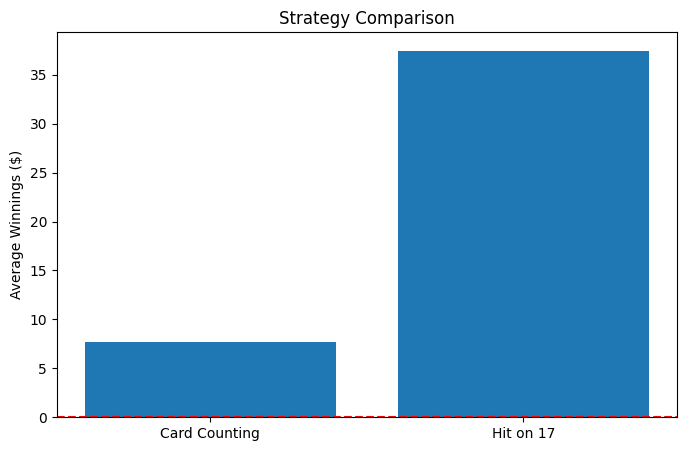

In [13]:
# Test new strategy vs card counting strategy

import matplotlib.pyplot as plt
import numpy as np

print("Testing Strategy 1 (Card Counting)...")
winnings_1=[]
for game_num in range(100):
    my_game=Game()
    my_game.level=my_game.CRITICAL
    
    my_game.add_player(Strategy_1_Player(threshold=0))
    my_game.add_player(DealerPlayer(threshold=16))
    my_game.add_player(DealerPlayer(threshold=16))
    my_game.add_player(DealerPlayer(threshold=16))
    
    my_game.play_game(50)
    
    strategy_player=my_game.all_players()[0]
    winnings=strategy_player.chips()-1000
    winnings_1.append(winnings)

avg_1=np.mean(winnings_1)
print(f"  Average: ${avg_1:.2f}")

print("\nTesting Strategy 2 (Hit on 17)...")
winnings_2=[]
for game_num in range(100):
    my_game=Game()
    my_game.level=my_game.CRITICAL
    
    my_game.add_player(Strategy_2_Player(hit_threshold=17))
    my_game.add_player(DealerPlayer(threshold=16))
    my_game.add_player(DealerPlayer(threshold=16))
    my_game.add_player(DealerPlayer(threshold=16))
    
    my_game.play_game(50)
    
    strategy_player=my_game.all_players()[0]
    winnings=strategy_player.chips()-1000
    winnings_2.append(winnings)

avg_2=np.mean(winnings_2)
print(f"  Average: ${avg_2:.2f}")

# Compare
print("\n========================================")
print("Strategy Comparison:")
print("========================================")
print(f"Card Counting (threshold=0): ${avg_1:.2f}")
print(f"Hit on 17 Strategy: ${avg_2:.2f}")

if avg_1>avg_2:
    print("\nCard counting performed better!")
elif avg_2>avg_1:
    print("\nHit on 17 performed better!")
else:
    print("\nBoth strategies tied!")

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(["Card Counting","Hit on 17"],[avg_1,avg_2])
plt.ylabel('Average Winnings ($)')
plt.title('Strategy Comparison')
plt.axhline(y=0,color='red',linestyle='--')
plt.show()